In [1]:
from tensorflow.keras.datasets.cifar10 import load_data
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Flatten, Dense, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.callbacks import ModelCheckpoint

2025-07-27 23:45:51.872274: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-27 23:45:51.872297: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-27 23:45:51.876785: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-27 23:45:51.911998: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


**Display Images**

In [2]:
def display_img(img_set, title_set):
  n = len(title_set)
  plt.figure(figsize=(10, 6))
  for i in range(n):
    plt.subplot(3, 3, i + 1)
    plt.imshow(img_set[i], cmap = 'gray')
    plt.title(np.argmax(title_set[i]))
  plt.tight_layout()
  plt.show()
  plt.close()

**Constants**

In [3]:
NUM_CLASSES = 10
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
BATCH_SIZE = 32
EPOCHS = 20

checkpoint_cb = ModelCheckpoint(
    "best_cnn_model.h5",           # filename to save
    save_best_only=True,           # only save when metric improves
    monitor="val_accuracy",        # metric to monitor
    mode="max",                    # maximize val_accuracy
    verbose=1
)

checkpoint_mb = ModelCheckpoint(
    "best_mbl_model.h5",           # filename to save
    save_best_only=True,           # only save when metric improves
    monitor="val_accuracy",        # metric to monitor
    mode="max",                    # maximize val_accuracy
    verbose=1
)

checkpoint_resnet = ModelCheckpoint(
    "best_resnet_model.h5",           # filename to save
    save_best_only=True,           # only save when metric improves
    monitor="val_accuracy",        # metric to monitor
    mode="max",                    # maximize val_accuracy
    verbose=1
)

checkpoint_distill = ModelCheckpoint(
    "best_distilled_model.h5",      # filename to save
    save_best_only=True,          # only save when metric improves
    monitor="val_categorical_accuracy", # The metric to monitor
    mode="max",                   # maximize the validation accuracy
    verbose=1
)

**Filter Dataset for 10 classes**

**Load Data and Preprocess data**

In [4]:
# Load CIFAR-10 dataset
(trainX, trainY), (testX, testY) = load_data()

# Split validation set from training data
split_index = int(0.8 * len(trainX))
valX, valY = trainX[split_index:], trainY[split_index:]
trainX, trainY = trainX[:split_index], trainY[:split_index]

# One hot encode the labels
trainY = to_categorical(trainY, NUM_CLASSES)
testY = to_categorical(testY, NUM_CLASSES)
valY = to_categorical(valY, NUM_CLASSES)

In [6]:
def preprocess(image, label, train=True):
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, [224, 224])
    if train:
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, max_delta=0.1)
        image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((trainX, trainY))
train_ds = train_ds.map(lambda x, y: preprocess(x, y, train=True)).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((valX, valY))
val_ds = val_ds.map(lambda x, y: preprocess(x, y, train=False)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((testX, testY))
test_ds = test_ds.map(lambda x, y: preprocess(x, y, train=False)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


2025-07-27 23:46:16.341594: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-27 23:46:16.799716: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-27 23:46:16.799974: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.19260988..1.0592196].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.080494374..1.1107855].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.09000701..1.0956984].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05763769..0.93456244].


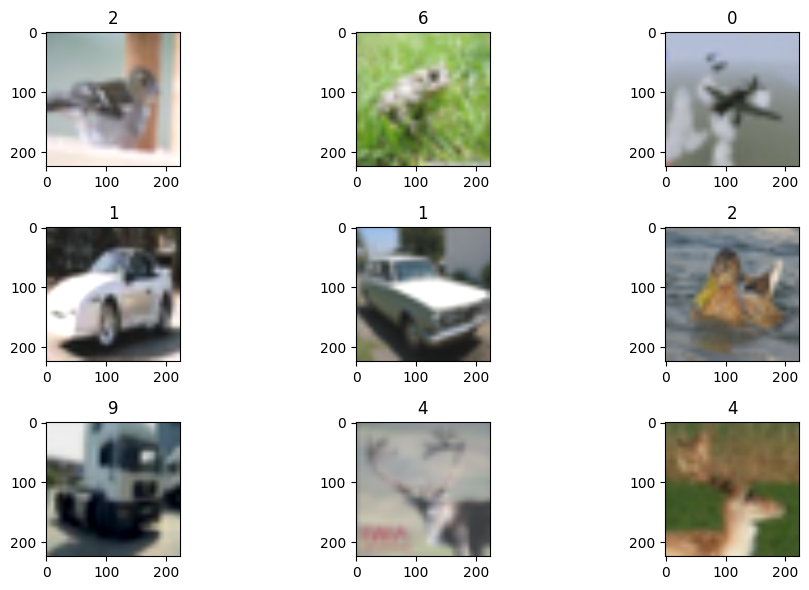

In [6]:
# show train_ds
for images, labels in train_ds.take(1):
    display_img(images[:9].numpy(), labels[:9].numpy())

**Build a CNN Model**

In [7]:
# Build a CNN Model
input_layer = Input(shape=(224, 224, 3))
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.GlobalMaxPooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
output_layer = Dense(NUM_CLASSES, activation='softmax')(x)
cnnModel = Model(inputs=input_layer, outputs=output_layer, name='Small_CNN_Model')
cnnModel.summary()

Model: "Small_CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 430,218 (1.64 MB)

 Trainable params: 430,218 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

**Compile & Train the Model**

In [8]:
cnnModel.compile(optimizer=Adam(learning_rate=0.0005),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# Compile & Train the Model
history = cnnModel.fit(train_ds,
                       validation_data=val_ds,
                       epochs=EPOCHS,
                       verbose=1,
                       callbacks=[checkpoint_cb])

Epoch 1/20


2025-07-27 15:13:52.376782: I external/local_xla/xla/service/service.cc:168] XLA service 0x780b1802d4a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-07-27 15:13:52.376810: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1070, Compute Capability 6.1
2025-07-27 15:13:52.449454: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-07-27 15:13:52.775971: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907


   2/1250 ━━━━━━━━━━━━━━━━━━━━ 1:20 65ms/step - accuracy: 0.1016 - loss: 2.3096  

I0000 00:00:1753607642.200504   17259 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2557 - loss: 1.9959
Epoch 1: val_accuracy improved from -inf to 0.43980, saving model to best_cnn_model.h5


...

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 126s 100ms/step - accuracy: 0.6554 - loss: 0.9667 - val_accuracy: 0.6427 - val_loss: 0.9973
Epoch 9/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.6717 - loss: 0.9215
Epoch 9: val_accuracy improved from 0.64270 to 0.65430, saving model to best_cnn_model.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 124s 99ms/step - accuracy: 0.6717 - loss: 0.9215 - val_accuracy: 0.6543 - val_loss: 0.9754
Epoch 10/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.6846 - loss: 0.8914
Epoch 10: val_accuracy did not improve from 0.65430
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 128s 102ms/step - accuracy: 0.6846 - loss: 0.8914 - val_accuracy: 0.6395 - val_loss: 1.0010
Epoch 11/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.6915 - loss: 0.8601
Epoch 11: val_accuracy improved from 0.65430 to 0.66210, saving model to best_cnn_model.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 129s 102ms/step - accuracy: 0.6915 - loss: 0.8601 - val_accuracy: 0.6621 - val_loss: 0.9513
Epoch 12/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.7023 - loss: 0.8352
Epoch 12: val_accuracy did not improve from 0.66210
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 129s 103ms/step - accuracy: 0.7023 - loss: 0.8352 - val_accuracy: 0.6601 - val_loss: 0.9664
Epoch 13/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.7079 - loss: 0.8130
Epoch 13: val_accuracy improved from 0.66210 to 0.67750, saving model to best_cnn_model.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 128s 101ms/step - accuracy: 0.7079 - loss: 0.8130 - val_accuracy: 0.6775 - val_loss: 0.9070
Epoch 14/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7172 - loss: 0.7943
Epoch 14: val_accuracy did not improve from 0.67750
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 124s 99ms/step - accuracy: 0.7172 - loss: 0.7943 - val_accuracy: 0.6745 - val_loss: 0.9236
Epoch 15/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7278 - loss: 0.7649
Epoch 15: val_accuracy did not improve from 0.67750
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 124s 98ms/step - accuracy: 0.7278 - loss: 0.7649 - val_accuracy: 0.6708 - val_loss: 0.9215
Epoch 16/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7353 - loss: 0.7431
Epoch 16: val_accuracy improved from 0.67750 to 0.69310, saving model to best_cnn_model.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 124s 98ms/step - accuracy: 0.7353 - loss: 0.7431 - val_accuracy: 0.6931 - val_loss: 0.8694
Epoch 17/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7421 - loss: 0.7241
Epoch 17: val_accuracy did not improve from 0.69310
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 123s 98ms/step - accuracy: 0.7421 - loss: 0.7241 - val_accuracy: 0.6835 - val_loss: 0.9025
Epoch 18/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7476 - loss: 0.7134
Epoch 18: val_accuracy did not improve from 0.69310
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 124s 98ms/step - accuracy: 0.7476 - loss: 0.7134 - val_accuracy: 0.6867 - val_loss: 0.9173
Epoch 19/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7575 - loss: 0.6878
Epoch 19: val_accuracy did not improve from 0.69310
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 124s 98ms/step - accuracy: 0.7575 - loss: 0.6878 - val_accuracy: 0.6895 - val_loss: 0.8823
Epoch 20/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7592 - loss: 0.6

**Evaluate the Model**

Test Loss: 0.876930296421051, Test Accuracy: 0.6916000247001648


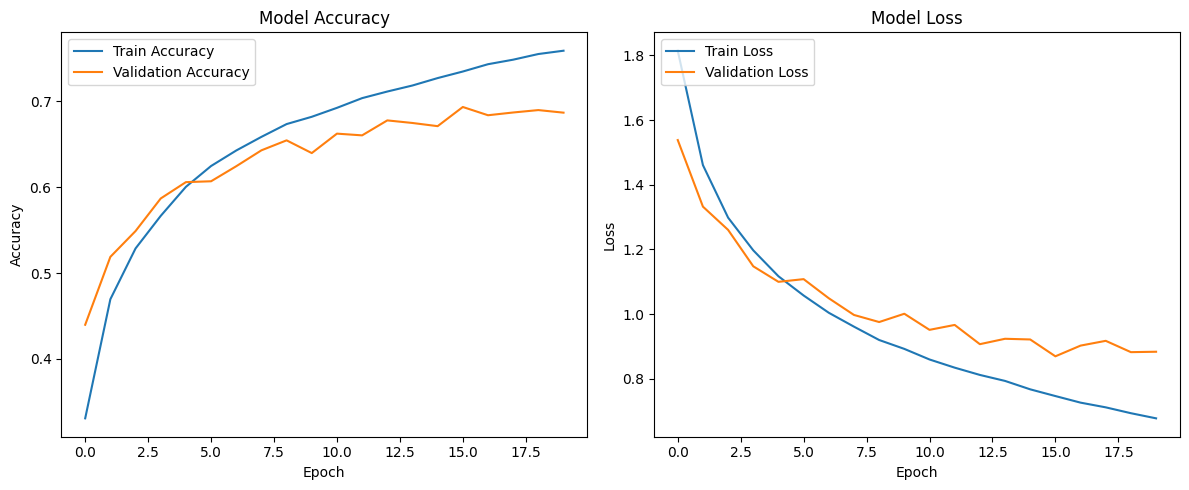

In [9]:
# Load the best checkpoint
cnnModel.load_weights("best_cnn_model.h5")

# Evaluate the model
test_loss, test_accuracy = cnnModel.evaluate(test_ds, verbose=0)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

# Plot accuracy and loss in a single figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(loc='upper left')

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(loc='upper left')
plt.tight_layout()
plt.show()


## preparing  your two favorite big CNNs, pre-trained by ImageNet dataset for 1000 classes, for classifying 10 classes of your chosen dataset by fine tuning last 1/2 layers

**Prepare MobileNetV2 Model and Resnet50V2 Model**

In [8]:
from tensorflow.keras.applications import MobileNetV2, ResNet50V2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess

def prepare_model(base_model, num_classes):
    base_model.trainable = False
    for layer in base_model.layers[-5:]:
        layer.trainable = True
    inputs = Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    return model

def preprocess_image_PT(images, label, preprocess_func, train=True):
    images = tf.image.resize(images, [224, 224])
    if train:
        images = tf.image.random_flip_left_right(images)
        images = tf.image.random_brightness(images, max_delta=0.1)
        images = tf.image.random_contrast(images, lower=0.9, upper=1.1)
    images = preprocess_func(images)
    return images, label

**MobileNetV2 Model**

In [11]:
# Prepare MobileNetV2 Model
mobilenet_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), include_top=False, weights='imagenet')
mobilenet_model = prepare_model(mobilenet_model, NUM_CLASSES)

# preprocess the data for MobileNetV2
train_ds_mobilenet = tf.data.Dataset.from_tensor_slices((trainX, trainY))
train_ds_mobilenet = train_ds_mobilenet.map(lambda x, y: preprocess_image_PT(x, y, mobilenet_preprocess, train=True)).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# preprocess the test data for MobileNetV2
test_ds_mobilenet = tf.data.Dataset.from_tensor_slices((testX, testY))
test_ds_mobilenet = test_ds_mobilenet.map(lambda x, y: preprocess_image_PT(x, y, mobilenet_preprocess, train=False)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Preprocess the validation data for MobileNetV2
val_ds_mobilenet = tf.data.Dataset.from_tensor_slices((valX, valY))
val_ds_mobilenet = val_ds_mobilenet.map(lambda x, y: preprocess_image_PT(x, y, mobilenet_preprocess, train=False)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7841 - loss: 0.6378
Epoch 1: val_accuracy improved from -inf to 0.79420, saving model to best_mbl_model.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 155s 97ms/step - accuracy: 0.7841 - loss: 0.6377 - val_accuracy: 0.7942 - val_loss: 0.8364
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8537 - loss: 0.4199
Epoch 2: val_accuracy did not improve from 0.79420
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 102s 80ms/step - accuracy: 0.8537 - loss: 0.4199 - val_accuracy: 0.6960 - val_loss: 1.3163
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8754 - loss: 0.3605
Epoch 3: val_accuracy improved from 0.79420 to 0.82730, saving model to best_mbl_model.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 102s 81ms/step - accuracy: 0.8754 - loss: 0.3605 - val_accuracy: 0.8273 - val_loss: 0.5724
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8897 - loss: 0.3201
Epoch 4: val_accuracy improved from 0.82730 to 0.84770, saving model to best_mbl_model.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 102s 80ms/step - accuracy: 0.8897 - loss: 0.3201 - val_accuracy: 0.8477 - val_loss: 0.5370
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9000 - loss: 0.2867
Epoch 5: val_accuracy improved from 0.84770 to 0.86710, saving model to best_mbl_model.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 102s 81ms/step - accuracy: 0.9000 - loss: 0.2867 - val_accuracy: 0.8671 - val_loss: 0.4325
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9093 - loss: 0.2612
Epoch 6: val_accuracy did not improve from 0.86710
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 102s 80ms/step - accuracy: 0.9093 - loss: 0.2612 - val_accuracy: 0.8624 - val_loss: 0.4628
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9161 - loss: 0.2378
Epoch 7: val_accuracy improved from 0.86710 to 0.87590, saving model to best_mbl_model.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 102s 81ms/step - accuracy: 0.9161 - loss: 0.2378 - val_accuracy: 0.8759 - val_loss: 0.3978
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9236 - loss: 0.2156
Epoch 8: val_accuracy did not improve from 0.87590
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 102s 80ms/step - accuracy: 0.9236 - loss: 0.2156 - val_accuracy: 0.8744 - val_loss: 0.4133
Epoch 9/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9310 - loss: 0.1910
Epoch 9: val_accuracy did not improve from 0.87590
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 102s 80ms/step - accuracy: 0.9310 - loss: 0.1910 - val_accuracy: 0.8646 - val_loss: 0.4797
Epoch 10/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9378 - loss: 0.1758
Epoch 10: val_accuracy did not improve from 0.87590
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 102s 80ms/step - accuracy: 0.9378 - loss: 0.1758 - val_accuracy: 0.8521 - val_loss: 0.5443
Epoch 11/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9439 - loss: 0.1553


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 105s 83ms/step - accuracy: 0.9656 - loss: 0.0958 - val_accuracy: 0.8787 - val_loss: 0.4704
Epoch 17/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9641 - loss: 0.0997
Epoch 17: val_accuracy improved from 0.87870 to 0.87890, saving model to best_mbl_model.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 108s 85ms/step - accuracy: 0.9641 - loss: 0.0997 - val_accuracy: 0.8789 - val_loss: 0.5076
Epoch 18/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9719 - loss: 0.0817
Epoch 18: val_accuracy improved from 0.87890 to 0.88160, saving model to best_mbl_model.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 108s 85ms/step - accuracy: 0.9719 - loss: 0.0817 - val_accuracy: 0.8816 - val_loss: 0.4816
Epoch 19/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9746 - loss: 0.0730
Epoch 19: val_accuracy did not improve from 0.88160
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 109s 86ms/step - accuracy: 0.9746 - loss: 0.0730 - val_accuracy: 0.8610 - val_loss: 0.5988
Epoch 20/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9731 - loss: 0.0737
Epoch 20: val_accuracy did not improve from 0.88160
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 107s 84ms/step - accuracy: 0.9731 - loss: 0.0737 - val_accuracy: 0.8769 - val_loss: 0.5453
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.8729 - loss: 0.5398
MobileNetV2 Test Loss: 0.5274419188499451, Test Accuracy: 0.8769000172615051


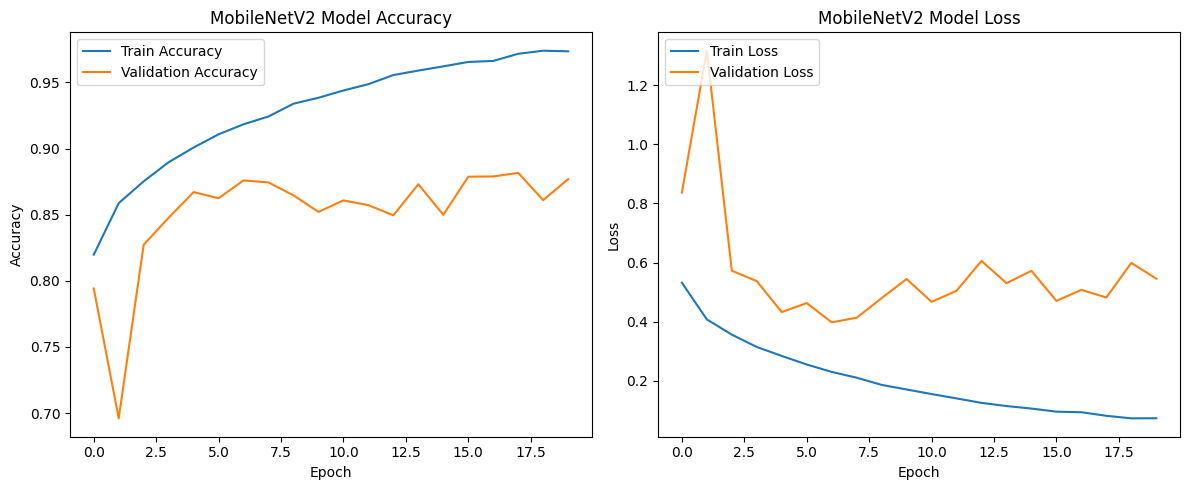

In [12]:
# Compile MobileNetV2 Model
mobilenet_model.compile(optimizer=Adam(learning_rate=0.0005),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])
# Train MobileNetV2 Model
history_mobilenet = mobilenet_model.fit(train_ds_mobilenet, epochs=EPOCHS,
                                        validation_data=val_ds_mobilenet,
                                        shuffle=True,
                                        verbose=1,
                                        callbacks=[checkpoint_mb])


# Load best checkpoint
mobilenet_model.load_weights("best_mbl_model.h5")

# Evaluate MobileNetV2 Model
test_loss_mobilenet, test_accuracy_mobilenet = mobilenet_model.evaluate(test_ds_mobilenet, verbose=1)
print(f"MobileNetV2 Test Loss: {test_loss_mobilenet}, Test Accuracy: {test_accuracy_mobilenet}")
# Plot MobileNetV2 accuracy and loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(history_mobilenet.history['accuracy'], label='Train Accuracy')
ax1.plot(history_mobilenet.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('MobileNetV2 Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(loc='upper left')
ax2.plot(history_mobilenet.history['loss'], label='Train Loss')
ax2.plot(history_mobilenet.history['val_loss'], label='Validation Loss')
ax2.set_title('MobileNetV2 Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(loc='upper left')
plt.tight_layout()
plt.show()

**Resnet50V2 Model**

In [9]:
# 2. Prepare ResNet50V2 datasets
train_ds_resnet = tf.data.Dataset.from_tensor_slices((trainX, trainY))
train_ds_resnet = train_ds_resnet.map(lambda x, y: preprocess_image_PT(x, y, resnet_preprocess, train=True)).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds_resnet = tf.data.Dataset.from_tensor_slices((testX, testY))
test_ds_resnet = test_ds_resnet.map(lambda x, y: preprocess_image_PT(x, y, resnet_preprocess, train=False)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds_resnet = tf.data.Dataset.from_tensor_slices((valX, valY))
val_ds_resnet = val_ds_resnet.map(lambda x, y: preprocess_image_PT(x, y, resnet_preprocess, train=False)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Epoch 1/20


2025-07-27 23:47:37.485641: I external/local_xla/xla/service/service.cc:168] XLA service 0x7c1a9402da00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-07-27 23:47:37.485667: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1070, Compute Capability 6.1
2025-07-27 23:47:37.662596: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-07-27 23:47:38.671142: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907


   2/1250 ━━━━━━━━━━━━━━━━━━━━ 1:26 70ms/step - accuracy: 0.1953 - loss: 2.3341  

I0000 00:00:1753638468.407692   67625 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8227 - loss: 0.5239
Epoch 1: val_accuracy improved from -inf to 0.84980, saving model to best_resnet_model.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 128s 89ms/step - accuracy: 0.8227 - loss: 0.5239 - val_accuracy: 0.8498 - val_loss: 0.4797
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9065 - loss: 0.2698
Epoch 2: val_accuracy improved from 0.84980 to 0.88590, saving model to best_resnet_model.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 103s 82ms/step - accuracy: 0.9065 - loss: 0.2698 - val_accuracy: 0.8859 - val_loss: 0.3414
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9317 - loss: 0.1982
Epoch 3: val_accuracy did not improve from 0.88590
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 101s 80ms/step - accuracy: 0.9317 - loss: 0.1982 - val_accuracy: 0.8751 - val_loss: 0.4122
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9429 - loss: 0.1614
Epoch 4: val_accuracy did not improve from 0.88590
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 101s 80ms/step - accuracy: 0.9429 - loss: 0.1614 - val_accuracy: 0.8778 - val_loss: 0.4152
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9591 - loss: 0.1190
Epoch 5: val_accuracy improved from 0.88590 to 0.88600, saving model to best_resnet_model.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 102s 81ms/step - accuracy: 0.9591 - loss: 0.1190 - val_accuracy: 0.8860 - val_loss: 0.3857
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9670 - loss: 0.0942
Epoch 6: val_accuracy did not improve from 0.88600
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 102s 80ms/step - accuracy: 0.9670 - loss: 0.0942 - val_accuracy: 0.8858 - val_loss: 0.4574
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9710 - loss: 0.0809
Epoch 7: val_accuracy improved from 0.88600 to 0.89430, saving model to best_resnet_model.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 102s 81ms/step - accuracy: 0.9710 - loss: 0.0809 - val_accuracy: 0.8943 - val_loss: 0.4436
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9780 - loss: 0.0634
Epoch 8: val_accuracy did not improve from 0.89430
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 101s 80ms/step - accuracy: 0.9780 - loss: 0.0634 - val_accuracy: 0.8914 - val_loss: 0.4350
Epoch 9/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9790 - loss: 0.0598
Epoch 9: val_accuracy did not improve from 0.89430
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 101s 80ms/step - accuracy: 0.9790 - loss: 0.0598 - val_accuracy: 0.8852 - val_loss: 0.5040
Epoch 10/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9837 - loss: 0.0492
Epoch 10: val_accuracy did not improve from 0.89430
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 102s 80ms/step - accuracy: 0.9837 - loss: 0.0492 - val_accuracy: 0.8885 - val_loss: 0.4971
Epoch 11/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9824 - loss: 0.0502


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 102s 81ms/step - accuracy: 0.9824 - loss: 0.0502 - val_accuracy: 0.8966 - val_loss: 0.5016
Epoch 12/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9867 - loss: 0.0390
Epoch 12: val_accuracy did not improve from 0.89660
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 101s 80ms/step - accuracy: 0.9867 - loss: 0.0390 - val_accuracy: 0.8917 - val_loss: 0.5062
Epoch 13/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9857 - loss: 0.0414
Epoch 13: val_accuracy did not improve from 0.89660
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 102s 80ms/step - accuracy: 0.9857 - loss: 0.0414 - val_accuracy: 0.8912 - val_loss: 0.5273
Epoch 14/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9869 - loss: 0.0375
Epoch 14: val_accuracy did not improve from 0.89660
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 102s 81ms/step - accuracy: 0.9869 - loss: 0.0375 - val_accuracy: 0.8851 - val_loss: 0.5960
Epoch 15/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9890 - loss: 0.0

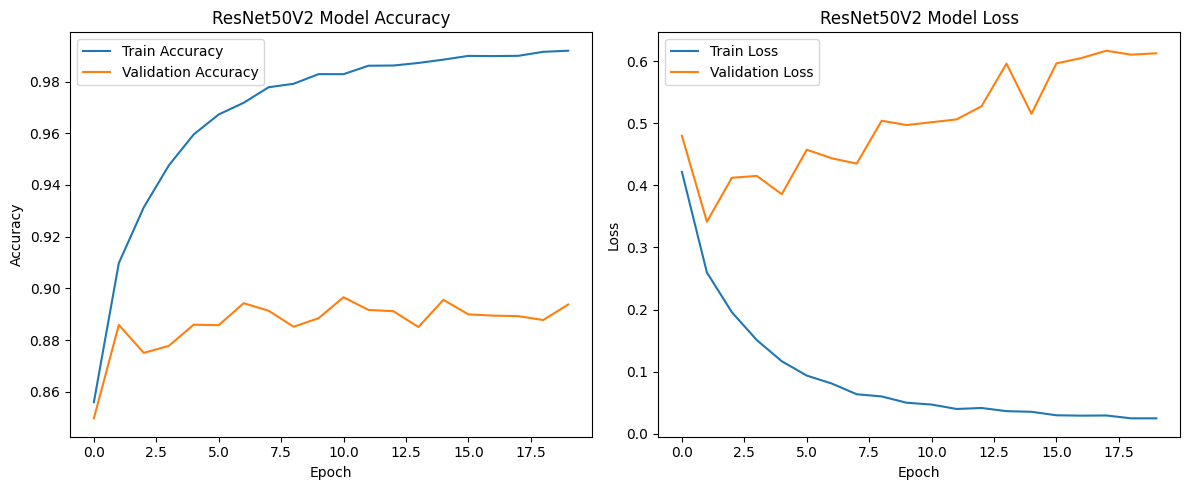

In [10]:
# 3. Prepare ResNet50V2 Model
resnet_model = ResNet50V2(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), include_top=False, weights='imagenet')
resnet_model = prepare_model(resnet_model, NUM_CLASSES)

# 4. Compile, train, and evaluate ResNet50V2 Model
resnet_model.compile(optimizer=Adam(learning_rate=0.0005),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

history_resnet = resnet_model.fit(train_ds_resnet, validation_data=val_ds_resnet,
                                  epochs=EPOCHS,
                                  shuffle=True,
                                  verbose=1,
                                  callbacks=[checkpoint_resnet])
# Load the best checkpoint
resnet_model.load_weights("best_resnet_model.h5")

# Evaluate ResNet50V2 Model
test_loss_resnet, test_accuracy_resnet = resnet_model.evaluate(test_ds_resnet, verbose=1)
print(f"ResNet50V2 Test Loss: {test_loss_resnet}, Test Accuracy: {test_accuracy_resnet}")

# Plot ResNet50V2 accuracy and loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(history_resnet.history['accuracy'], label='Train Accuracy')
ax1.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('ResNet50V2 Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(loc='upper left')
ax2.plot(history_resnet.history['loss'], label='Train Loss')
ax2.plot(history_resnet.history['val_loss'], label='Validation Loss')
ax2.set_title('ResNet50V2 Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Transferring knowledge from your big fine-tuned one classifier to your own small CNN

**ResNet50V2 as Teacher Model**

In [11]:
import keras
from keras import ops

**Define the Distiller Class**

In [12]:
class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.1,
        temperature=3,
    ):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def compute_loss(
        self, x=None, y=None, y_pred=None, sample_weight=None, allow_empty=False
    ):

        teacher_pred = self.teacher(x, training=False)
        student_loss = self.student_loss_fn(y, y_pred)

        distillation_loss = self.distillation_loss_fn(
            ops.softmax(teacher_pred / self.temperature, axis=1),
            ops.softmax(y_pred / self.temperature, axis=1),
        ) * (self.temperature**2)

        loss = self.alpha * student_loss + (1 - self.alpha) * distillation_loss
        return loss

    def call(self, x):
        return self.student(x)

**Prepare Models for Distillation**

In [13]:
# --- Student Model (Logits version) ---
input_layer_student = Input(shape=(224, 224, 3), name="student_input")
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer_student)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.GlobalMaxPooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
output_layer_student = Dense(NUM_CLASSES, name="student_logits_output")(x)

student_for_distillation = Model(inputs=input_layer_student, outputs=output_layer_student, name='Student_CNN_For_Distillation')

# --- Teacher Model (Logits version) ---
# Get the original ResNet50V2 base
resnet_base_teacher = ResNet50V2(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), include_top=False, weights='imagenet')
resnet_base_teacher.trainable = False
for layer in resnet_base_teacher.layers[-5:]:
    layer.trainable = True

# Create the new head, ensuring the final Dense layer has NO activation function.
inputs = Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
x = resnet_base_teacher(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(NUM_CLASSES)(x)  # This layer now outputs logits.
teacher_for_distillation = Model(inputs, outputs, name='teacher_logits')

# Load the weights from your best-performing fine-tuned model.
teacher_for_distillation.load_weights("best_resnet_model.h5")

print("Student and Teacher models ready for distillation (outputting logits).")

Student and Teacher models ready for distillation (outputting logits).


**Distill Knowledge to the Student**

In [14]:
# Initialize and compile the distiller
distiller = Distiller(student=student_for_distillation, teacher=teacher_for_distillation)
distiller.compile(
    optimizer=Adam(learning_rate=0.0005),
    metrics=[keras.metrics.CategoricalAccuracy()],
    student_loss_fn=keras.losses.CategoricalCrossentropy(from_logits=True),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.1,
    temperature=10,
)

# Train the distiller model
print("\nStarting distillation from Teacher (ResNet50V2) to Student (Small CNN)...")
history_distill = distiller.fit(train_ds_resnet,
                                validation_data=val_ds_resnet,
                                epochs=EPOCHS,
                                verbose=1,
                                callbacks=[checkpoint_distill])


Starting distillation from Teacher (ResNet50V2) to Student (Small CNN)...
Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - categorical_accuracy: 0.2404 - loss: 1.6105
Epoch 1: val_categorical_accuracy improved from -inf to 0.48300, saving model to best_distilled_model.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 178s 128ms/step - categorical_accuracy: 0.2405 - loss: 1.6095 - val_categorical_accuracy: 0.4830 - val_loss: 0.2204
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - categorical_accuracy: 0.4932 - loss: 0.2194
Epoch 2: val_categorical_accuracy improved from 0.48300 to 0.55970, saving model to best_distilled_model.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 156s 124ms/step - categorical_accuracy: 0.4932 - loss: 0.2194 - val_categorical_accuracy: 0.5597 - val_loss: 0.2158
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - categorical_accuracy: 0.5687 - loss: 0.2147
Epoch 3: val_categorical_accuracy improved from 0.55970 to 0.58300, saving model to best_distilled_model.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 156s 124ms/step - categorical_accuracy: 0.5687 - loss: 0.2147 - val_categorical_accuracy: 0.5830 - val_loss: 0.2094
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - categorical_accuracy: 0.5990 - loss: 0.2006
Epoch 4: val_categorical_accuracy improved from 0.58300 to 0.60090, saving model to best_distilled_model.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 156s 124ms/step - categorical_accuracy: 0.5990 - loss: 0.2006 - val_categorical_accuracy: 0.6009 - val_loss: 0.1907
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - categorical_accuracy: 0.6321 - loss: 0.1868
Epoch 5: val_categorical_accuracy improved from 0.60090 to 0.63720, saving model to best_distilled_model.h5


...

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 156s 124ms/step - categorical_accuracy: 0.7432 - loss: 0.1384 - val_categorical_accuracy: 0.7042 - val_loss: 0.1631
Epoch 13/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - categorical_accuracy: 0.7482 - loss: 0.1358
Epoch 13: val_categorical_accuracy improved from 0.70420 to 0.71070, saving model to best_distilled_model.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 156s 124ms/step - categorical_accuracy: 0.7482 - loss: 0.1358 - val_categorical_accuracy: 0.7107 - val_loss: 0.1599
Epoch 14/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - categorical_accuracy: 0.7561 - loss: 0.1315
Epoch 14: val_categorical_accuracy did not improve from 0.71070
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 155s 123ms/step - categorical_accuracy: 0.7561 - loss: 0.1315 - val_categorical_accuracy: 0.7080 - val_loss: 0.1630
Epoch 15/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - categorical_accuracy: 0.7626 - loss: 0.1294
Epoch 15: val_categorical_accuracy improved from 0.71070 to 0.72120, saving model to best_distilled_model.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 156s 124ms/step - categorical_accuracy: 0.7626 - loss: 0.1294 - val_categorical_accuracy: 0.7212 - val_loss: 0.1607
Epoch 16/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - categorical_accuracy: 0.7751 - loss: 0.1253
Epoch 16: val_categorical_accuracy improved from 0.72120 to 0.72380, saving model to best_distilled_model.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 156s 124ms/step - categorical_accuracy: 0.7751 - loss: 0.1253 - val_categorical_accuracy: 0.7238 - val_loss: 0.1694
Epoch 17/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - categorical_accuracy: 0.7803 - loss: 0.1223
Epoch 17: val_categorical_accuracy did not improve from 0.72380
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 155s 123ms/step - categorical_accuracy: 0.7803 - loss: 0.1223 - val_categorical_accuracy: 0.7227 - val_loss: 0.1656
Epoch 18/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - categorical_accuracy: 0.7823 - loss: 0.1209
Epoch 18: val_categorical_accuracy improved from 0.72380 to 0.73060, saving model to best_distilled_model.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 158s 126ms/step - categorical_accuracy: 0.7823 - loss: 0.1209 - val_categorical_accuracy: 0.7306 - val_loss: 0.1610
Epoch 19/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - categorical_accuracy: 0.7888 - loss: 0.1173
Epoch 19: val_categorical_accuracy did not improve from 0.73060
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 157s 125ms/step - categorical_accuracy: 0.7888 - loss: 0.1173 - val_categorical_accuracy: 0.7301 - val_loss: 0.1661
Epoch 20/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - categorical_accuracy: 0.7948 - loss: 0.1148
Epoch 20: val_categorical_accuracy did not improve from 0.73060
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 155s 123ms/step - categorical_accuracy: 0.7948 - loss: 0.1148 - val_categorical_accuracy: 0.7221 - val_loss: 0.1702


**Evaluate the Distilled Student**


Loading weights from the best distilled model...

Evaluating the distilled student model...
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - categorical_accuracy: 0.7342 - loss: 0.1613
Distilled Student Test Loss: 0.16085132956504822, Test Accuracy: 0.7336999773979187


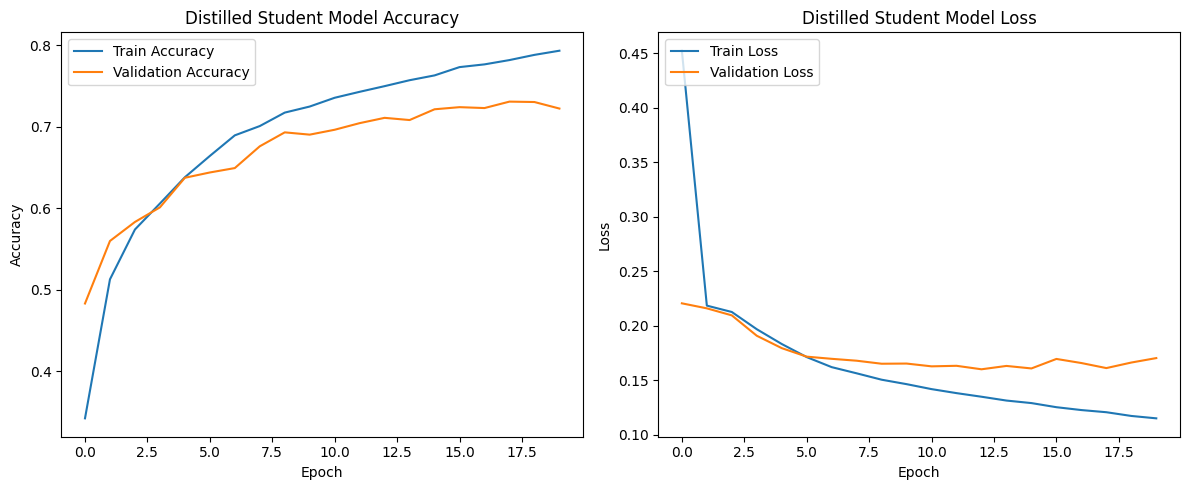

In [15]:
# Load the best weights saved by the checkpoint
print("\nLoading weights from the best distilled model...")
distiller.load_weights("best_distilled_model.h5")

# Evaluate the distilled model on the test set
print("\nEvaluating the distilled student model...")
distilled_test_loss, distilled_test_accuracy = distiller.evaluate(test_ds_resnet)
print(f"Distilled Student Test Loss: {distilled_test_loss}, Test Accuracy: {distilled_test_accuracy}")

# You can also plot its performance, similar to the other models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(history_distill.history['categorical_accuracy'], label='Train Accuracy')
ax1.plot(history_distill.history['val_categorical_accuracy'], label='Validation Accuracy')
ax1.set_title('Distilled Student Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(loc='upper left')

ax2.plot(history_distill.history['loss'], label='Train Loss')
ax2.plot(history_distill.history['val_loss'], label='Validation Loss')
ax2.set_title('Distilled Student Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(loc='upper left')
plt.tight_layout()
plt.show()

##Transferring Knowledge from Two Fine-Tuned Classifiers

In [16]:
class DistillerWithTwoTeachers(keras.Model):
    def __init__(self, student, teachers):
        super().__init__()
        self.student = student
        self.teacher1 = teachers[0]
        self.teacher2 = teachers[1]

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.1,
        temperature=3,
    ):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def compute_loss(
        self, x=None, y=None, y_pred=None, sample_weight=None, allow_empty=False
    ):
        # Get predictions from both teachers (non-trainable)
        teacher_pred_1 = self.teacher1(x, training=False)
        teacher_pred_2 = self.teacher2(x, training=False)

        # Calculate the student's loss on the ground truth
        student_loss = self.student_loss_fn(y, y_pred)

        # Calculate distillation loss from the first teacher
        distillation_loss_1 = self.distillation_loss_fn(
            ops.softmax(teacher_pred_1 / self.temperature, axis=1),
            ops.softmax(y_pred / self.temperature, axis=1),
        ) * (self.temperature**2)

        # Calculate distillation loss from the second teacher
        distillation_loss_2 = self.distillation_loss_fn(
            ops.softmax(teacher_pred_2 / self.temperature, axis=1),
            ops.softmax(y_pred / self.temperature, axis=1),
        ) * (self.temperature**2)

        # Average the distillation losses
        avg_distillation_loss = (distillation_loss_1 + distillation_loss_2) / 2

        # Combine student and distillation losses
        loss = self.alpha * student_loss + (1 - self.alpha) * avg_distillation_loss
        return loss

    def call(self, x):
        return self.student(x)

In [18]:
# --- Student Model (Logits version) ---
# (Reusing the same architecture as before)
input_layer_student_two = Input(shape=(224, 224, 3), name="student_input_two")
x_s = Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer_student_two)
x_s = MaxPooling2D((2, 2))(x_s)
x_s = Conv2D(64, (3, 3), activation='relu', padding='same')(x_s)
x_s = MaxPooling2D((2, 2))(x_s)
x_s = Conv2D(128, (3, 3), activation='relu', padding='same')(x_s)
x_s = MaxPooling2D((2, 2))(x_s)
x_s = Conv2D(256, (3, 3), activation='relu', padding='same')(x_s)
x_s = tf.keras.layers.GlobalMaxPooling2D()(x_s)
x_s = Dense(128, activation='relu')(x_s)
x_s = Dense(64, activation='relu')(x_s)
output_layer_student_two = Dense(NUM_CLASSES, name="student_logits_output_two")(x_s)
student_for_multi_distillation = Model(inputs=input_layer_student_two, outputs=output_layer_student_two, name='Student_CNN_For_Multi_Distillation')

# --- Teacher Models (Logits version) ---
# Teacher 1: ResNet50V2
resnet_base_teacher = ResNet50V2(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), include_top=False, weights='imagenet')
resnet_base_teacher.trainable = False
inputs_t1 = Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
x_t1 = resnet_base_teacher(inputs_t1, training=False)
x_t1 = tf.keras.layers.GlobalAveragePooling2D()(x_t1)
x_t1 = Dense(128, activation='relu')(x_t1)
outputs_t1 = Dense(NUM_CLASSES)(x_t1)
teacher1_for_distillation = Model(inputs_t1, outputs_t1, name='teacher1_logits')
teacher1_for_distillation.load_weights("best_resnet_model.h5")

# Teacher 2: MobileNetV2
mobilenet_base_teacher = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), include_top=False, weights='imagenet')
mobilenet_base_teacher.trainable = False
inputs_t2 = Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
x_t2 = mobilenet_base_teacher(inputs_t2, training=False)
x_t2 = tf.keras.layers.GlobalAveragePooling2D()(x_t2)
x_t2 = Dense(128, activation='relu')(x_t2)
outputs_t2 = Dense(NUM_CLASSES)(x_t2)
teacher2_for_distillation = Model(inputs_t2, outputs_t2, name='teacher2_logits')
teacher2_for_distillation.load_weights("best_mbl_model.h5")

print("Student and Teacher models are ready for multi-teacher distillation.")

#### **Distill Knowledge from Both Teachers**
## Now, we compile and train the `DistillerWithTwoTeachers` model. We use the ResNet50V2 preprocessed data, as it is compatible with MobileNetV2.

# A new checkpoint callback for the multi-teacher model
checkpoint_distill_two = ModelCheckpoint(
    "best_distilled_model_two_teachers.h5",
    save_best_only=True,
    monitor="val_categorical_accuracy",
    mode="max",
    verbose=1
)

# Initialize and compile the distiller with two teachers
distiller_two_teachers = DistillerWithTwoTeachers(
    student=student_for_multi_distillation,
    teachers=[teacher1_for_distillation, teacher2_for_distillation]
)
distiller_two_teachers.compile(
    optimizer=Adam(learning_rate=0.0005),
    metrics=[keras.metrics.CategoricalAccuracy()],
    student_loss_fn=keras.losses.CategoricalCrossentropy(from_logits=True),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.1,
    temperature=10,
)

# Train the distiller model
print("\nStarting distillation from two teachers to the Student CNN...")
history_distill_two = distiller_two_teachers.fit(
    train_ds_resnet,
    validation_data=val_ds_resnet,
    epochs=EPOCHS,
    verbose=1,
    callbacks=[checkpoint_distill_two]
)

Student and Teacher models are ready for multi-teacher distillation.

Starting distillation from two teachers to the Student CNN...
Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - categorical_accuracy: 0.2938 - loss: 3.5800
Epoch 1: val_categorical_accuracy improved from -inf to 0.46190, saving model to best_distilled_model_two_teachers.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 224s 162ms/step - categorical_accuracy: 0.2938 - loss: 3.5779 - val_categorical_accuracy: 0.4619 - val_loss: 0.2260
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - categorical_accuracy: 0.4863 - loss: 0.2232
Epoch 2: val_categorical_accuracy improved from 0.46190 to 0.52720, saving model to best_distilled_model_two_teachers.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 194s 154ms/step - categorical_accuracy: 0.4863 - loss: 0.2232 - val_categorical_accuracy: 0.5272 - val_loss: 0.2191
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - categorical_accuracy: 0.5443 - loss: 0.2178
Epoch 3: val_categorical_accuracy improved from 0.52720 to 0.55180, saving model to best_distilled_model_two_teachers.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 194s 154ms/step - categorical_accuracy: 0.5443 - loss: 0.2178 - val_categorical_accuracy: 0.5518 - val_loss: 0.2157
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - categorical_accuracy: 0.5884 - loss: 0.2133
Epoch 4: val_categorical_accuracy improved from 0.55180 to 0.58030, saving model to best_distilled_model_two_teachers.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 194s 154ms/step - categorical_accuracy: 0.5884 - loss: 0.2133 - val_categorical_accuracy: 0.5803 - val_loss: 0.2063
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - categorical_accuracy: 0.6034 - loss: 0.1989
Epoch 5: val_categorical_accuracy improved from 0.58030 to 0.62100, saving model to best_distilled_model_two_teachers.h5


...

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 194s 154ms/step - categorical_accuracy: 0.7368 - loss: 0.1539 - val_categorical_accuracy: 0.7111 - val_loss: 0.1626
Epoch 12/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - categorical_accuracy: 0.7466 - loss: 0.1503
Epoch 12: val_categorical_accuracy did not improve from 0.71110
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 193s 154ms/step - categorical_accuracy: 0.7466 - loss: 0.1503 - val_categorical_accuracy: 0.7070 - val_loss: 0.1606
Epoch 13/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - categorical_accuracy: 0.7569 - loss: 0.1475
Epoch 13: val_categorical_accuracy did not improve from 0.71110
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 193s 154ms/step - categorical_accuracy: 0.7569 - loss: 0.1475 - val_categorical_accuracy: 0.6970 - val_loss: 0.1666
Epoch 14/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - categorical_accuracy: 0.7648 - loss: 0.1450
Epoch 14: val_categorical_accuracy improved from 0.71110 to 0.71820, saving model to best_distilled_model_two_teachers.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 194s 154ms/step - categorical_accuracy: 0.7648 - loss: 0.1450 - val_categorical_accuracy: 0.7182 - val_loss: 0.1587
Epoch 15/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - categorical_accuracy: 0.7744 - loss: 0.1416
Epoch 15: val_categorical_accuracy did not improve from 0.71820
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 194s 154ms/step - categorical_accuracy: 0.7744 - loss: 0.1416 - val_categorical_accuracy: 0.7153 - val_loss: 0.1646
Epoch 16/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - categorical_accuracy: 0.7821 - loss: 0.1403
Epoch 16: val_categorical_accuracy improved from 0.71820 to 0.72610, saving model to best_distilled_model_two_teachers.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 194s 154ms/step - categorical_accuracy: 0.7821 - loss: 0.1403 - val_categorical_accuracy: 0.7261 - val_loss: 0.1622
Epoch 17/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - categorical_accuracy: 0.7886 - loss: 0.1373
Epoch 17: val_categorical_accuracy did not improve from 0.72610
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 194s 154ms/step - categorical_accuracy: 0.7886 - loss: 0.1373 - val_categorical_accuracy: 0.7224 - val_loss: 0.1624
Epoch 18/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - categorical_accuracy: 0.7951 - loss: 0.1362
Epoch 18: val_categorical_accuracy improved from 0.72610 to 0.72670, saving model to best_distilled_model_two_teachers.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 194s 154ms/step - categorical_accuracy: 0.7951 - loss: 0.1362 - val_categorical_accuracy: 0.7267 - val_loss: 0.1600
Epoch 19/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - categorical_accuracy: 0.8048 - loss: 0.1332
Epoch 19: val_categorical_accuracy improved from 0.72670 to 0.73980, saving model to best_distilled_model_two_teachers.h5


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 194s 154ms/step - categorical_accuracy: 0.8048 - loss: 0.1332 - val_categorical_accuracy: 0.7398 - val_loss: 0.1586
Epoch 20/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - categorical_accuracy: 0.8053 - loss: 0.1321
Epoch 20: val_categorical_accuracy did not improve from 0.73980
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 193s 154ms/step - categorical_accuracy: 0.8053 - loss: 0.1321 - val_categorical_accuracy: 0.7390 - val_loss: 0.1603



Loading weights from the best distilled model with two teachers...

Evaluating the distilled student model on the test set...
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 99ms/step - categorical_accuracy: 0.7350 - loss: 0.1597
Distilled Student (Two Teachers) Test Loss: 0.15989308059215546, Test Accuracy: 0.7343000173568726


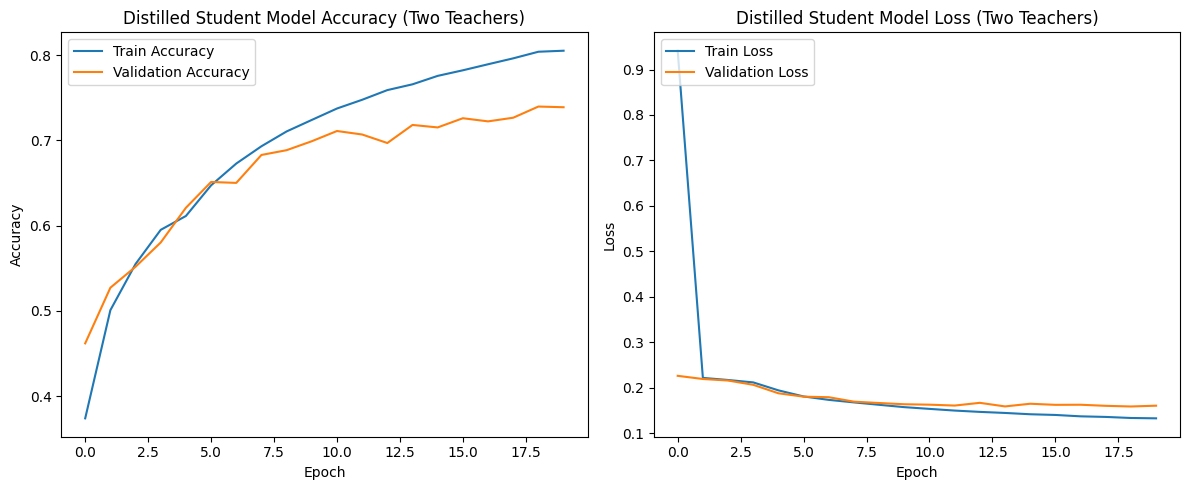

: 

In [ ]:
# Load the best weights saved by the checkpoint
print("\nLoading weights from the best distilled model with two teachers...")
distiller_two_teachers.load_weights("best_distilled_model_two_teachers.h5")

# Evaluate the distilled model on the test set
print("\nEvaluating the distilled student model on the test set...")
distilled_test_loss, distilled_test_accuracy = distiller_two_teachers.evaluate(test_ds_resnet)
print(f"Distilled Student (Two Teachers) Test Loss: {distilled_test_loss}, Test Accuracy: {distilled_test_accuracy}")


# Plot the accuracy and loss for the distilled model with two teachers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Accuracy
ax1.plot(history_distill_two.history['categorical_accuracy'], label='Train Accuracy')
ax1.plot(history_distill_two.history['val_categorical_accuracy'], label='Validation Accuracy')
ax1.set_title('Distilled Student Model Accuracy (Two Teachers)')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(loc='upper left')

# Plot Loss
ax2.plot(history_distill_two.history['loss'], label='Train Loss')
ax2.plot(history_distill_two.history['val_loss'], label='Validation Loss')
ax2.set_title('Distilled Student Model Loss (Two Teachers)')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()